In [17]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint
import generate_data
from datasets import LetterStringDataset
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Batching Example

In [29]:
ds = LetterStringDataset(mode="val", data_dir="../data/all_transformations_study1", batch_size=4, batching_method="unstructured", query_first=False)
dataloader = DataLoader(ds, batch_sampler=ds.sampler, collate_fn=ds.collate_fn)

In [30]:
for i, batch in enumerate(dataloader):
    if i > 5:
        break
    print(f"\n\nBatch {i+1}")
    for i in range(len(batch["xq_context"])):
        print(f"[{batch["transformation"][i]}], [{batch["alphabet"][i]}]")
        print(f"{" ".join(batch["xq_context"][i])}\n")



Batch 1
[shift], [a b c u e v g h d k i l m j r p q o s t f n w x y z]
a b c u e v g h d k i l m j r p q o s t f n w x y z SOS b c u e IO v g h d SOS a b c u e v

[replicate], [a z c d e f g h i j k l m n o p q r s t u v w x y b]
a z c d e f g h i j k l m n o p q r s t u v w x y b SOS m n o p q r s IO m n o p q r s m n o p q r s SOS j k l

[fix_alphabetic_seq], [a b c d g f e h i j k l m n o p q r s t u v w x y z]
a b c d g f e h i j k l m n o p q r s t u v w x y z SOS a k l m n o p IO j k l m n o p SOS k e m n o p

[fix_interleave], [a b c d e f g h i j k l m n o p q r s t u v w x y z]
a b c d e f g h i j k l m n o p q r s t u v w x y z SOS l e m e k IO l e m e n SOS h y w y x y y y z



Batch 2
[rr_succ], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS m n n o p q r s IO m n o p q r t SOS m n n o

[succ], [a b c d x f g i r j k l m n o p q h s t u v w e y z]
a b c d x f g i r j k l m n o p q h s t u v w e y z SOS v w e I

## Results

In [3]:
unstructured = checkpoint.CheckPoint(path="../models/MLC_batchunstruct_dallstudy1_nep20.pt", device=DEVICE)
unstructured_query_first = checkpoint.CheckPoint(path="../models/MLC_batchunstruct_qf_dallstudy1_nep20.pt", device=DEVICE)
by_trans = checkpoint.CheckPoint(path="../models/MLC_batchbytrans_dallstudy1_nep20.pt", device=DEVICE)
by_alph = checkpoint.CheckPoint(path="../models/MLC_batchbyalph_dallstudy1_nep20.pt", device=DEVICE)
by_both = checkpoint.CheckPoint(path="../models/MLC_batchbyboth_dallstudy1_nep20.pt", device=DEVICE)
all_training_runs = [unstructured, unstructured_query_first, by_trans, by_alph, by_both]

In [4]:
data = [train_run.args for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["loss"] = round(train_run.checkpoint["best_val_loss"], 3)
    data[i]["accuracy in-dist"] = round(np.max([x["in"] for x in train_run.checkpoint["val_accuracy"]]), 3)
    data[i]["accuracy out-of-dist"] = round(np.max([x["out-of"] for x in train_run.checkpoint["val_accuracy"]]), 3)
df = pd.DataFrame(data)
print("Shared Arguments:")
shared_arguments = df.loc[:, df.nunique() == 1].drop(["dir_model", "save_best", "save_best_skip", "resume", "print_batches"], axis=1).rename(columns={"dir_data": "dataset"})
shared_arguments.loc[0,:].to_markdown("table_batching_shared_params.md")
shared_arguments.loc[0,:]

Shared Arguments:


dataset            data/all_transformations_study1
batch_size                                      32
nepochs                                         20
lr                                           0.001
lr_end_factor                                 0.05
lr_warmup                                     True
nlayers_encoder                                  3
nlayers_decoder                                  3
nheads                                           8
emb_size                                       128
ff_mult                                          4
dropout                                        0.1
act                                           gelu
Name: 0, dtype: object

In [5]:
df.loc[:, df.nunique() > 1]

,filename_model,sampling_method,query_first,loss,accuracy in-dist,accuracy out-of-dist
0,MLC_batchunstruct_dallstudy1_nep20.pt,unstructured,False,1.079,0.680,0.118
1,MLC_batchunstruct_qf_dallstudy1_nep20.pt,unstructured,True,1.090,0.623,0.086
2,MLC_batchbytrans_dallstudy1_nep20.pt,transformation,False,1.203,0.640,0.121
3,MLC_batchbyalph_dallstudy1_nep20.pt,alphabet,False,1.112,0.618,0.084
4,MLC_batchbyboth_dallstudy1_nep20.pt,both,False,1.257,0.602,0.098


In [6]:
df.loc[:, df.nunique() > 1].to_markdown("table_batching.md", index=False)

In [7]:
easier_val = checkpoint.CheckPoint(path="../models/MLC_all_trans_study1_nep20_lr0_0005_bs64_dr0_2_io_easy_val.pt", device=DEVICE)

In [15]:
print("Easier Validation set")
print(f"Best Val Loss: {round(easier_val.checkpoint["best_val_loss"], 3)}")
print(f"Best Val Acc (in-dist): {round(np.max([x["in"] for x in easier_val.checkpoint["val_accuracy"]]), 3)}")
print(f"Best Val Acc (out-of-dist): {round(np.max([x["out-of"] for x in easier_val.checkpoint["val_accuracy"]]), 3)}")

Easier Validation set
Best Val Loss: 1.017
Best Val Acc (in-dist): 0.774
Best Val Acc (out-of-dist): 0.128


In [32]:
model = easier_val.load_model()

Loading model that has completed (or started) 20 of 20 epochs
	batch size: 64
	number of steps:57,520
	best val loss achieved: 1.0168
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.2 dropout


Best Validation Loss: 1.017


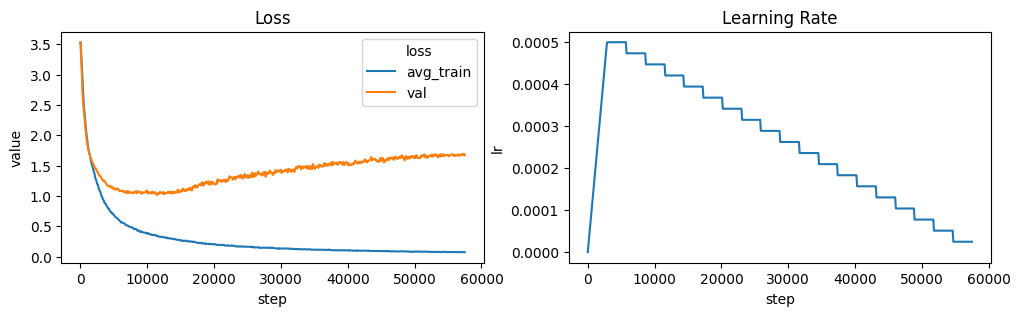

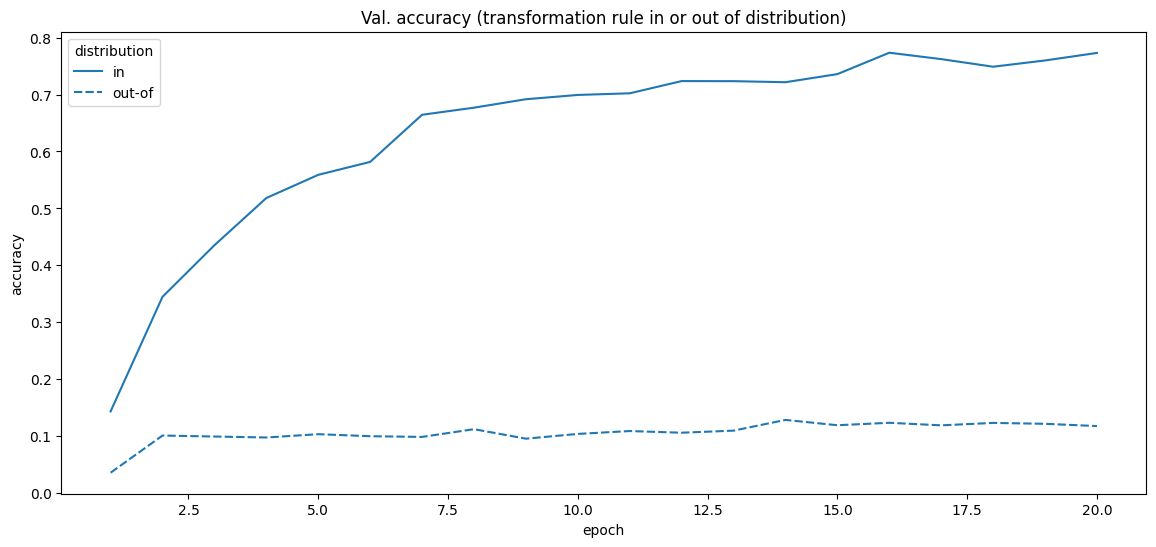

In [41]:
checkpoint = easier_val
fig1, ax1 = plt.subplots(1, 2, figsize=(12,3))
ax1[0] = checkpoint.plot_loss(ax1[0])
_ = ax1[0].set_title("Loss")
ax1[1] = checkpoint.plot_learning_rate(ax1[1])
_ = ax1[1].set_title("Learning Rate")
print(f'Best Validation Loss: {checkpoint.checkpoint["best_val_loss"]:.3f}')

val_acc = pd.DataFrame(checkpoint.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["in","out-of"] , var_name="distribution", value_name="accuracy")
fig, ax = plt.subplots(figsize=(14,6))
_ = sns.lineplot(data=val_acc, x="epoch", y="accuracy", style="distribution", ax=ax)
_ = ax.set_title("Val. accuracy (transformation rule in or out of distribution)")

In [16]:
easier_val.args["dir_data"]

'data/all_transformations_study1_easier_val'